# TB Detection Model — Sehat-AI
**Binary classifier: TB Positive / TB Negative from chest X-rays**

### Pipeline Overview
1. Install & imports
2. Kaggle setup & dataset download
3. CLAHE preprocessing function
4. Build dataset folders (1:1 balanced)
5. Class weights
6. Data generators
7. Build MobileNetV2 model
8. Phase 1 training (frozen base)
9. Phase 2 fine-tuning
10. Evaluate & plot
11. Threshold tuning (recall-focused)
12. Confusion matrix
13. Grad-CAM setup
14. Export model & metadata
15. Test cell with upload & Grad-CAM

> **Before running:** Set runtime to GPU — Runtime > Change runtime type > T4 GPU

In [1]:
# ── Cell 1 — Install & Imports ────────────────────────────────────────────────
!pip install tensorflow kaggle pillow opencv-python scikit-learn seaborn matplotlib -q

import os
import shutil
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import io
import json

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                         ModelCheckpoint)
from sklearn.metrics import (confusion_matrix, classification_report,
                               f1_score, precision_score, recall_score,
                               accuracy_score, roc_curve, auc as sklearn_auc)
from sklearn.utils.class_weight import compute_class_weight
from PIL import Image

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# ── Cell 2 — Kaggle Setup & Dataset Download ──────────────────────────────────
from google.colab import files
files.upload()  # upload kaggle.json when prompted

os.makedirs('/root/.config/kaggle', exist_ok=True)
os.system('cp kaggle.json /root/.config/kaggle/kaggle.json')
os.system('chmod 600 /root/.config/kaggle/kaggle.json')

# Primary TB dataset — NIAID sourced (700 TB + 3500 Normal)
!kaggle datasets download -d tawsifurrahman/tuberculosis-tb-chest-xray-dataset \
    -p /content/raw/ --unzip -q

# Paul Mooney — used only for supplementing Normal class
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia \
    -p /content/raw/ --unzip -q

print("Downloads complete.")

# Verify folder structure
import subprocess
result = subprocess.run(['find', '/content/raw', '-type', 'd', '-maxdepth', '4'],
                       capture_output=True, text=True)
print(result.stdout)

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/tuberculosis-tb-chest-xray-dataset
License(s): copyright-authors
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
Downloads complete.
/content/raw
/content/raw/TB_Chest_Radiography_Database
/content/raw/TB_Chest_Radiography_Database/Tuberculosis
/content/raw/TB_Chest_Radiography_Database/Normal
/content/raw/chest_xray
/content/raw/chest_xray/val
/content/raw/chest_xray/val/PNEUMONIA
/content/raw/chest_xray/val/NORMAL
/content/raw/chest_xray/__MACOSX
/content/raw/chest_xray/__MACOSX/chest_xray
/content/raw/chest_xray/__MACOSX/chest_xray/val
/content/raw/chest_xray/__MACOSX/chest_xray/train
/content/raw/chest_xray/__MACOSX/chest_xray/test
/content/raw/chest_xray/train
/content/raw/chest_xray/train/PNEUMONIA
/content/raw/chest_xray/train/NORMAL
/content/raw/chest_xray/chest_xray
/content/raw/chest_xray/chest_xray/val
/content/raw/chest_xray/che

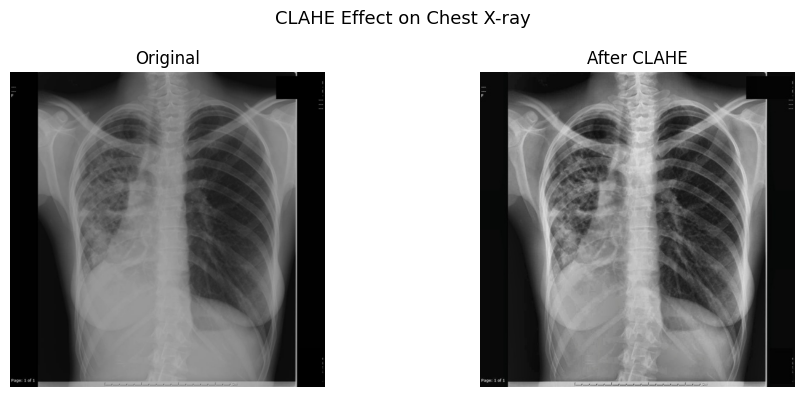

CLAHE function ready.


In [3]:
# ── Cell 3 — CLAHE Preprocessing Function ────────────────────────────────────
# CLAHE (Contrast Limited Adaptive Histogram Equalization)
# Enhances local contrast to make subtle TB features more visible:
#   - Faint cavitations become more distinct
#   - Upper lobe infiltrates stand out more clearly
#   - Fibrotic scars have better edge definition

def apply_clahe(image_path, output_path):
    img = cv2.imread(str(image_path))
    if img is None:
        return False
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_enhanced = clahe.apply(l)
    lab_enhanced = cv2.merge([l_enhanced, a, b])
    img_enhanced = cv2.cvtColor(lab_enhanced, cv2.COLOR_LAB2BGR)
    cv2.imwrite(str(output_path), img_enhanced)
    return True


def show_clahe_comparison(image_path):
    original = cv2.imread(str(image_path))
    original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    temp_path = '/content/temp_clahe_test.jpg'
    apply_clahe(image_path, temp_path)
    enhanced = cv2.imread(temp_path)
    enhanced_rgb = cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(original_rgb)
    axes[0].set_title('Original')
    axes[0].axis('off')
    axes[1].imshow(enhanced_rgb)
    axes[1].set_title('After CLAHE')
    axes[1].axis('off')
    plt.suptitle('CLAHE Effect on Chest X-ray', fontsize=13)
    plt.tight_layout()
    plt.show()


# Demo on a sample image
sample_images = list(Path('/content/raw').rglob('*.png'))[:1]
if not sample_images:
    sample_images = list(Path('/content/raw').rglob('*.jpg'))[:1]

if sample_images:
    show_clahe_comparison(sample_images[0])
    print("CLAHE function ready.")
else:
    print("Could not find sample image — check Cell 2 folder output.")

In [4]:
# ── Cell 4a — Locate Dataset Folders ─────────────────────────────────────────
# Run this first, check the output, then run Cell 4b

tb_possible_roots = [
    '/content/raw/TB_Chest_Xray_Database',
    '/content/raw/tuberculosis-tb-chest-xray-dataset',
    '/content/raw',
]

tb_positive_dir = None
tb_normal_dir   = None

for root in tb_possible_roots:
    r = Path(root)
    if not r.exists():
        continue
    for sub in r.rglob('*'):
        if sub.is_dir() and sub.name.lower() in ['tuberculosis', 'tb']:
            tb_positive_dir = sub
        if sub.is_dir() and sub.name.lower() == 'normal':
            if 'chest_xray' not in str(sub):
                tb_normal_dir = sub

print(f"TB positive folder : {tb_positive_dir}")
print(f"TB normal folder   : {tb_normal_dir}")

TB positive folder : /content/raw/TB_Chest_Radiography_Database/Tuberculosis
TB normal folder   : /content/raw/TB_Chest_Radiography_Database/Normal


In [5]:
# ── Cell 4b — Build 1:1 Balanced Dataset with CLAHE ──────────────────────────
random.seed(42)

# Clear and recreate folders
for folder in ['/content/dataset/tb_positive', '/content/dataset/tb_negative']:
    if os.path.exists(folder):
        shutil.rmtree(folder)
    os.makedirs(folder)

# ── TB Positive — copy all TB images ─────────────────────────────────────────
tb_images = []
if tb_positive_dir:
    for ext in ['*.png', '*.jpg', '*.jpeg']:
        tb_images += list(tb_positive_dir.glob(ext))

random.shuffle(tb_images)
failed = 0
for img_path in tb_images:
    out_path = Path(f'/content/dataset/tb_positive/{img_path.stem}.png')
    if not apply_clahe(img_path, out_path):
        failed += 1

tb_count = len(os.listdir('/content/dataset/tb_positive'))
print(f"TB positive copied : {tb_count}  (failed: {failed})")

# ── TB Negative — exactly match TB count (1:1) ────────────────────────────────
normal_tb_images = []
if tb_normal_dir:
    for ext in ['*.png', '*.jpg', '*.jpeg']:
        normal_tb_images += list(tb_normal_dir.glob(ext))

mooney_normal = Path('/content/raw/chest_xray/train/NORMAL')
mooney_images = []
if mooney_normal.exists():
    mooney_images = (list(mooney_normal.glob('*.jpeg')) +
                     list(mooney_normal.glob('*.jpg')))

all_normals = normal_tb_images + mooney_images
random.shuffle(all_normals)

# Strictly 1:1
target_normals = tb_count
print(f"Available normals  : {len(all_normals)} — sampling {target_normals}")

for i, img_path in enumerate(all_normals[:target_normals]):
    out_path = Path(f'/content/dataset/tb_negative/normal_{i}.png')
    apply_clahe(img_path, out_path)

pos = len(os.listdir('/content/dataset/tb_positive'))
neg = len(os.listdir('/content/dataset/tb_negative'))
print(f"\nFinal → TB positive: {pos} | TB negative: {neg}")
print(f"Ratio: 1:{neg/pos:.1f}  ← should be exactly 1:1")

TB positive copied : 700  (failed: 0)
Available normals  : 4841 — sampling 700

Final → TB positive: 700 | TB negative: 700
Ratio: 1:1.0  ← should be exactly 1:1


In [6]:
# ── Cell 5 — Class Weights ────────────────────────────────────────────────────
# Dataset is 1:1 but we give TB a 1.5x penalty
# to keep the model biased toward recall (catching TB cases)

pos = len(os.listdir('/content/dataset/tb_positive'))
neg = len(os.listdir('/content/dataset/tb_negative'))

class_weights = {0: 1.0, 1: 1.5}

print(f"Dataset      : {pos} TB positive | {neg} TB negative")
print(f"Class weights: {class_weights}")
print("TB class gets 1.5x penalty — biases toward recall without heavy imbalance")
print("\nClass index mapping (alphabetical):")
print("  0 = tb_negative")
print("  1 = tb_positive")

Dataset      : 700 TB positive | 700 TB negative
Class weights: {0: 1.0, 1: 1.5}
TB class gets 1.5x penalty — biases toward recall without heavy imbalance

Class index mapping (alphabetical):
  0 = tb_negative
  1 = tb_positive


In [7]:
# ── Cell 6 — Data Generators ──────────────────────────────────────────────────
# IMPORTANT: NO horizontal_flip — chest X-rays are anatomically directional
# Flipping puts the heart on the wrong side (looks like dextrocardia)
# TB location (upper lobe) is anatomically fixed — keep rotation_range small

IMG_SIZE   = (224, 224)
BATCH_SIZE = 16  # smaller batch = better gradient signal on small dataset

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=8,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.1,
    brightness_range=[0.85, 1.15],
    shear_range=0.05,
    fill_mode='nearest'
    # NO horizontal_flip
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    '/content/dataset/',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True,
    seed=42
)

val_gen = val_datagen.flow_from_directory(
    '/content/dataset/',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False,
    seed=42
)

print("Class indices      :", train_gen.class_indices)
print(f"Training batches   : {len(train_gen)}")
print(f"Validation batches : {len(val_gen)}")
print(f"Training samples   : ~{len(train_gen) * BATCH_SIZE}")
print(f"Validation samples : ~{len(val_gen) * BATCH_SIZE}")

# Verify class weights align with class indices
print("\nClass weight alignment:")
for name, idx in train_gen.class_indices.items():
    print(f"  {name} (index {idx}) → weight {class_weights[idx]}")

Found 1120 images belonging to 2 classes.
Found 280 images belonging to 2 classes.
Class indices      : {'tb_negative': 0, 'tb_positive': 1}
Training batches   : 70
Validation batches : 18
Training samples   : ~1120
Validation samples : ~288

Class weight alignment:
  tb_negative (index 0) → weight 1.0
  tb_positive (index 1) → weight 1.5


In [8]:
# ── Cell 7 — Build MobileNetV2 Model ─────────────────────────────────────────
# MobileNetV2 chosen over EfficientNetB0 for TB detection because:
#   - Better performance on small datasets (~700 images per class)
#   - Less prone to overfitting with limited medical data
#   - Lighter model (~14MB) — faster inference in backend
#   - Proven in TB research literature on similar dataset sizes

def build_tb_model():
    base = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )
    base.trainable = False

    inputs = tf.keras.Input(shape=(224, 224, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.Precision(name='precision')
        ]
    )
    return model

model = build_tb_model()
model.summary()

trainable     = sum([tf.size(w).numpy() for w in model.trainable_weights])
non_trainable = sum([tf.size(w).numpy() for w in model.non_trainable_weights])
print(f"\nTrainable params     : {trainable:,}")
print(f"Non-trainable params : {non_trainable:,}")
print("Phase 1: only classification head trains — base is frozen")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,435,393 (9.29 MB)

 Trainable params: 174,849 (683.00 KB)

 Non-trainable params: 2,260,544 (8.62 MB)


Trainable params     : 174,849
Non-trainable params : 2,260,544
Phase 1: only classification head trains — base is frozen


In [16]:
# ── Cell 8 — Phase 1 Training (Frozen Base) ───────────────────────────────────
# Monitor val_auc (not val_accuracy) — AUC is more reliable on medical data
# accuracy can be misleading even at 1:1 if model is uncertain

callbacks_phase1 = [
    EarlyStopping(
        monitor='val_auc',
        patience=6,
        restore_best_weights=True,
        mode='max'
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        '/content/best_tb_model.h5',
        monitor='val_auc',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

print("Phase 1: Training classification head with frozen MobileNetV2...")
print(f"Class weights: {class_weights}\n")

history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    callbacks=callbacks_phase1,
    class_weight=class_weights
)

Phase 1: Training classification head with frozen MobileNetV2...
Class weights: {0: 1.0, 1: 1.5}

Epoch 1/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.9597 - auc: 0.9897 - loss: 0.1552 - precision: 0.9547 - recall: 0.9643
Epoch 1: val_auc improved from None to 0.99390, saving model to /content/best_tb_model.h5



Epoch 1: finished saving model to /content/best_tb_model.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 39s 551ms/step - accuracy: 0.9473 - auc: 0.9877 - loss: 0.1773 - precision: 0.9449 - recall: 0.9500 - val_accuracy: 0.9714 - val_auc: 0.9939 - val_loss: 0.0807 - val_precision: 0.9583 - val_recall: 0.9857 - learning_rate: 1.0000e-05
Epoch 2/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.9333 - auc: 0.9805 - loss: 0.2302 - precision: 0.9072 - recall: 0.9621
Epoch 2: val_auc improved from 0.99390 to 0.99393, saving model to /content/best_tb_model.h5



Epoch 2: finished saving model to /content/best_tb_model.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 33s 476ms/step - accuracy: 0.9321 - auc: 0.9802 - loss: 0.2285 - precision: 0.9130 - recall: 0.9554 - val_accuracy: 0.9750 - val_auc: 0.9939 - val_loss: 0.0915 - val_precision: 0.9586 - val_recall: 0.9929 - learning_rate: 1.0000e-05
Epoch 3/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.9531 - auc: 0.9881 - loss: 0.1505 - precision: 0.9510 - recall: 0.9591
Epoch 3: val_auc improved from 0.99393 to 0.99416, saving model to /content/best_tb_model.h5



Epoch 3: finished saving model to /content/best_tb_model.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 34s 486ms/step - accuracy: 0.9679 - auc: 0.9946 - loss: 0.1084 - precision: 0.9613 - recall: 0.9750 - val_accuracy: 0.9786 - val_auc: 0.9942 - val_loss: 0.0863 - val_precision: 0.9653 - val_recall: 0.9929 - learning_rate: 1.0000e-05
Epoch 4/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.9608 - auc: 0.9927 - loss: 0.1310 - precision: 0.9553 - recall: 0.9680
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

Epoch 4: val_auc improved from 0.99416 to 0.99444, saving model to /content/best_tb_model.h5



Epoch 4: finished saving model to /content/best_tb_model.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 34s 480ms/step - accuracy: 0.9643 - auc: 0.9938 - loss: 0.1232 - precision: 0.9626 - recall: 0.9661 - val_accuracy: 0.9750 - val_auc: 0.9944 - val_loss: 0.0825 - val_precision: 0.9586 - val_recall: 0.9929 - learning_rate: 1.0000e-05
Epoch 5/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.9735 - auc: 0.9972 - loss: 0.0798 - precision: 0.9605 - recall: 0.9861
Epoch 5: val_auc improved from 0.99444 to 0.99459, saving model to /content/best_tb_model.h5



Epoch 5: finished saving model to /content/best_tb_model.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 33s 477ms/step - accuracy: 0.9714 - auc: 0.9960 - loss: 0.0922 - precision: 0.9648 - recall: 0.9786 - val_accuracy: 0.9714 - val_auc: 0.9946 - val_loss: 0.0827 - val_precision: 0.9583 - val_recall: 0.9857 - learning_rate: 5.0000e-06
Epoch 6/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.9701 - auc: 0.9965 - loss: 0.0899 - precision: 0.9666 - recall: 0.9747
Epoch 6: val_auc improved from 0.99459 to 0.99474, saving model to /content/best_tb_model.h5



Epoch 6: finished saving model to /content/best_tb_model.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 34s 482ms/step - accuracy: 0.9661 - auc: 0.9953 - loss: 0.1023 - precision: 0.9595 - recall: 0.9732 - val_accuracy: 0.9750 - val_auc: 0.9947 - val_loss: 0.0845 - val_precision: 0.9650 - val_recall: 0.9857 - learning_rate: 5.0000e-06
Epoch 7/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.9699 - auc: 0.9973 - loss: 0.0856 - precision: 0.9614 - recall: 0.9775
Epoch 7: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.

Epoch 7: val_auc did not improve from 0.99474
70/70 ━━━━━━━━━━━━━━━━━━━━ 33s 473ms/step - accuracy: 0.9652 - auc: 0.9961 - loss: 0.1013 - precision: 0.9594 - recall: 0.9714 - val_accuracy: 0.9679 - val_auc: 0.9945 - val_loss: 0.0878 - val_precision: 0.9580 - val_recall: 0.9786 - learning_rate: 5.0000e-06
Epoch 8/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.9668 - auc: 0.9966 - loss: 0.0975 - precision: 0.9493 - recall: 0.9834
Epoch 8: val_auc did n

In [17]:
# ── Cell 9 — Phase 2 Fine-tuning ──────────────────────────────────────────────
# Unfreeze last 30 layers of MobileNetV2
# These high-level layers learn TB-specific patterns:
#   - Upper lobe infiltrates
#   - Cavitation patterns
#   - Fibrotic textures
# Learning rate 1e-5 (100x smaller) to avoid destroying pre-trained features

model.load_weights('/content/best_tb_model.h5')

base_model = model.get_layer('mobilenetv2_1.00_224')
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum([1 for l in base_model.layers if l.trainable])
print(f"MobileNetV2 layers total     : {len(base_model.layers)}")
print(f"Unfrozen for fine-tuning     : {trainable_count}")
print(f"Still frozen                 : {len(base_model.layers) - trainable_count}")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.Precision(name='precision')
    ]
)

callbacks_phase2 = [
    EarlyStopping(
        monitor='val_auc',
        patience=7,
        restore_best_weights=True,
        mode='max'
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-8,
        verbose=1
    ),
    ModelCheckpoint(
        '/content/best_tb_model.h5',
        monitor='val_auc',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

print("\nPhase 2: Fine-tuning last 30 MobileNetV2 layers...")
history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks_phase2,
    class_weight=class_weights
)

MobileNetV2 layers total     : 154
Unfrozen for fine-tuning     : 30
Still frozen                 : 124

Phase 2: Fine-tuning last 30 MobileNetV2 layers...
Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.9683 - auc: 0.9946 - loss: 0.1024 - precision: 0.9740 - recall: 0.9666
Epoch 1: val_auc improved from None to 0.99526, saving model to /content/best_tb_model.h5



Epoch 1: finished saving model to /content/best_tb_model.h5
70/70 ━━━━━━━━━━━━━━━━━━━━ 66s 685ms/step - accuracy: 0.9714 - auc: 0.9946 - loss: 0.0999 - precision: 0.9664 - recall: 0.9768 - val_accuracy: 0.9786 - val_auc: 0.9953 - val_loss: 0.0813 - val_precision: 0.9786 - val_recall: 0.9786 - learning_rate: 1.0000e-05
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.9702 - auc: 0.9960 - loss: 0.0933 - precision: 0.9716 - recall: 0.9723
Epoch 2: val_auc did not improve from 0.99526
70/70 ━━━━━━━━━━━━━━━━━━━━ 33s 465ms/step - accuracy: 0.9688 - auc: 0.9944 - loss: 0.1037 - precision: 0.9597 - recall: 0.9786 - val_accuracy: 0.9714 - val_auc: 0.9948 - val_loss: 0.0858 - val_precision: 0.9648 - val_recall: 0.9786 - learning_rate: 1.0000e-05
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.9788 - auc: 0.9930 - loss: 0.0939 - precision: 0.9798 - recall: 0.9790
Epoch 3: val_auc did not improve from 0.99526
70/70 ━━━━━━━━━━━━━━━━━━━━ 33s 477ms/step - accuracy:

18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 205ms/step - accuracy: 0.9786 - auc: 0.9953 - loss: 0.0813 - precision: 0.9786 - recall: 0.9786

--- Final Validation Results ---
  loss        : 0.0813
  compile_metrics: 0.9786


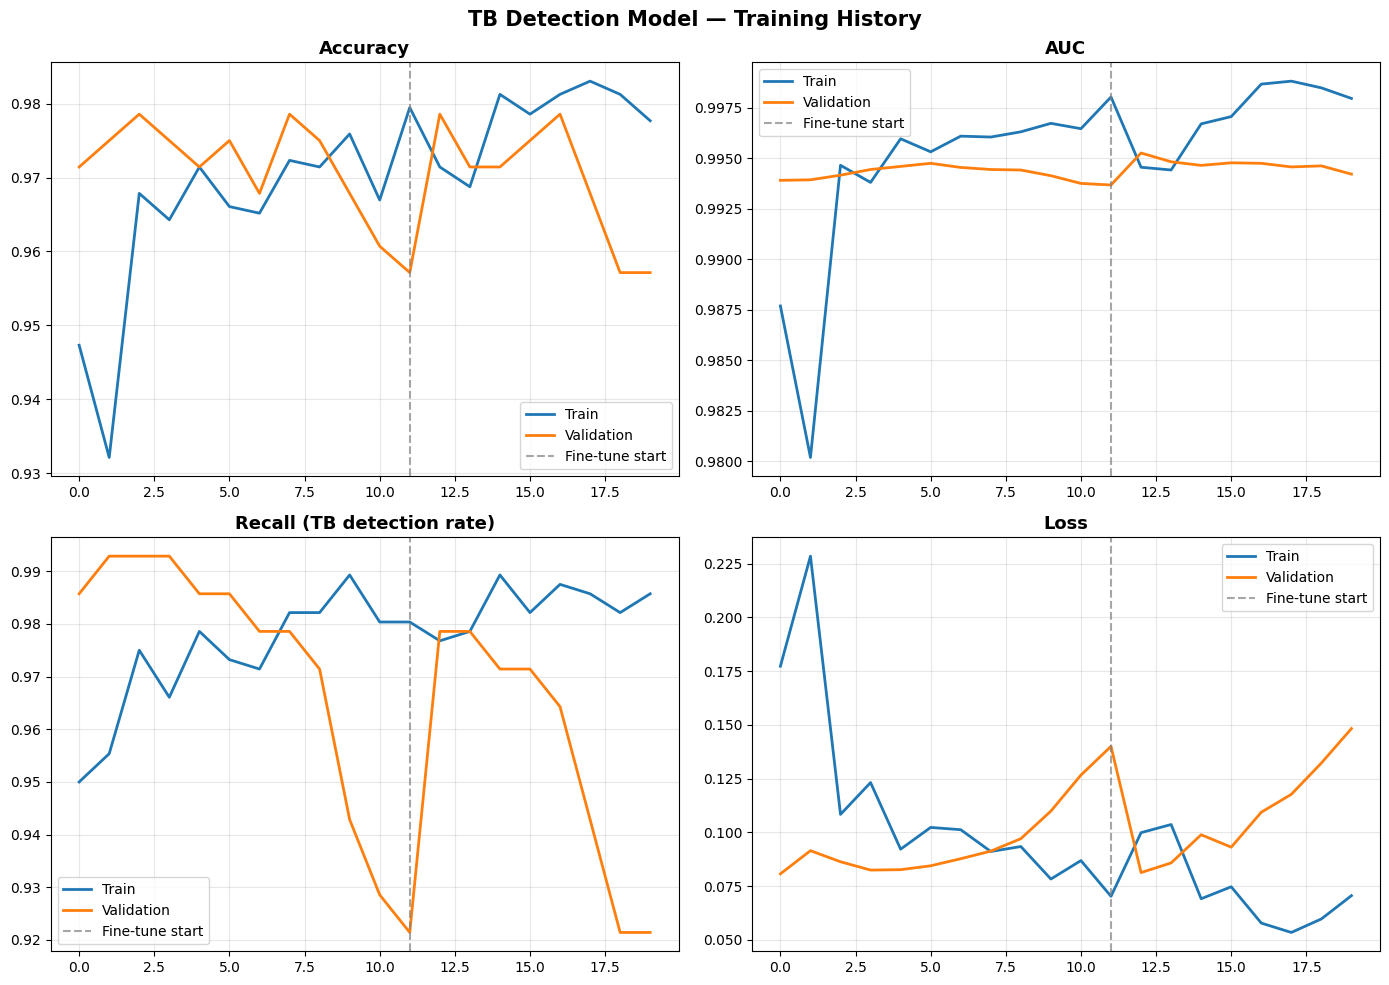

Saved: tb_training_curves.png


In [18]:
# ── Cell 10 — Evaluate & Plot Training Curves ─────────────────────────────────

model.load_weights('/content/best_tb_model.h5')

results = model.evaluate(val_gen, verbose=1)
metrics_dict = dict(zip(model.metrics_names, results))
print("\n--- Final Validation Results ---")
for k, v in metrics_dict.items():
    print(f"  {k:12s}: {v:.4f}")

def merge(h1, h2, key):
    return h1.history.get(key, []) + h2.history.get(key, [])

phase1_len = len(history1.history.get('loss', []))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, metric, title in zip(
    axes.flat,
    ['accuracy', 'auc', 'recall', 'loss'],
    ['Accuracy', 'AUC', 'Recall (TB detection rate)', 'Loss']
):
    train_vals = merge(history1, history2, metric)
    val_vals   = merge(history1, history2, f'val_{metric}')
    ax.plot(train_vals, label='Train', linewidth=2)
    ax.plot(val_vals,   label='Validation', linewidth=2)
    ax.axvline(x=phase1_len - 1, color='gray',
               linestyle='--', alpha=0.7, label='Fine-tune start')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('TB Detection Model — Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/tb_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: tb_training_curves.png")

18/18 ━━━━━━━━━━━━━━━━━━━━ 63s 3s/step


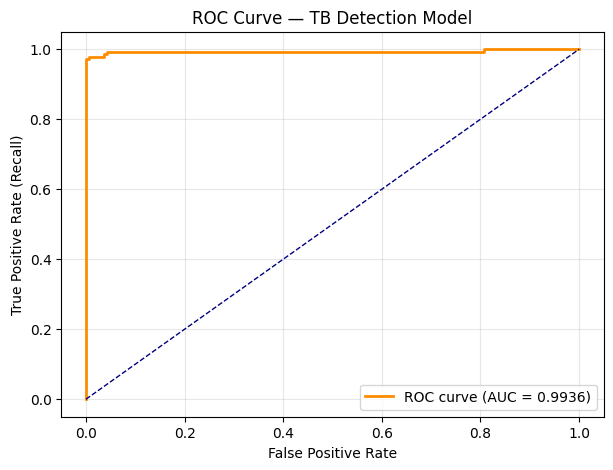


Threshold | Accuracy | Precision | Recall  | F1     | FN (missed TB)
---------------------------------------------------------------------------
  0.20    |  0.971   |   0.952   |  0.993  | 0.972  | 1
  0.25    |  0.971   |   0.958   |  0.986  | 0.972  | 2
  0.30    |  0.971   |   0.958   |  0.986  | 0.972  | 2
  0.35    |  0.971   |   0.965   |  0.979  | 0.972  | 3
  0.40    |  0.975   |   0.972   |  0.979  | 0.975  | 3
  0.45    |  0.975   |   0.972   |  0.979  | 0.975  | 3
  0.50    |  0.979   |   0.979   |  0.979  | 0.979  | 3
  0.55    |  0.982   |   0.986   |  0.979  | 0.982  | 3
  0.60    |  0.986   |   0.993   |  0.979  | 0.986  | 3
  0.65    |  0.986   |   0.993   |  0.979  | 0.986  | 3
  0.70    |  0.982   |   0.993   |  0.971  | 0.982  | 4
  0.75    |  0.982   |   1.000   |  0.964  | 0.982  | 5
  0.80    |  0.971   |   1.000   |  0.943  | 0.971  | 8

Selected threshold : 0.75
Recall at threshold: 0.9643
Strategy: maximise recall — missing TB is more harmful than false alarm

In [19]:
# ── Cell 11 — Threshold Tuning (Recall-focused) ───────────────────────────────
# Strategy: find threshold where recall >= 0.90
# Missing TB (false negative) is far more dangerous than a false alarm

val_gen.reset()
y_pred_probs = model.predict(val_gen, verbose=1).flatten()
y_true       = val_gen.classes

# ── ROC Curve ─────────────────────────────────────────────────────────────────
fpr, tpr, roc_thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = sklearn_auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — TB Detection Model')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig('/content/tb_roc_curve.png', dpi=150)
plt.show()

# ── Threshold search ──────────────────────────────────────────────────────────
print("\nThreshold | Accuracy | Precision | Recall  | F1     | FN (missed TB)")
print("-" * 75)

thresholds     = np.arange(0.2, 0.8, 0.05)
best_threshold = 0.5
best_recall    = 0
best_precision_at_recall = 0

for t in thresholds:
    y_pred = (y_pred_probs >= t).astype(int)
    acc    = accuracy_score(y_true, y_pred)
    prec   = precision_score(y_true, y_pred, zero_division=0)
    rec    = recall_score(y_true, y_pred, zero_division=0)
    f1     = f1_score(y_true, y_pred, zero_division=0)
    cm_t   = confusion_matrix(y_true, y_pred)
    fn     = cm_t[1][0] if cm_t.shape == (2, 2) else 0
    print(f"  {t:.2f}    |  {acc:.3f}   |   {prec:.3f}   |  {rec:.3f}  | {f1:.3f}  | {fn}")
    # Select threshold with recall >= 0.90 and best precision among those
    if rec >= 0.90 and prec > best_precision_at_recall:
        best_threshold = t
        best_recall    = rec
        best_precision_at_recall = prec

# Fallback: if no threshold reaches 0.90 recall, pick highest recall
if best_recall == 0:
    print("\nNote: no threshold reached 0.90 recall — selecting highest available")
    for t in thresholds:
        y_pred = (y_pred_probs >= t).astype(int)
        rec = recall_score(y_true, y_pred, zero_division=0)
        if rec > best_recall:
            best_recall    = rec
            best_threshold = t

print(f"\nSelected threshold : {best_threshold:.2f}")
print(f"Recall at threshold: {best_recall:.4f}")
print("Strategy: maximise recall — missing TB is more harmful than false alarm")

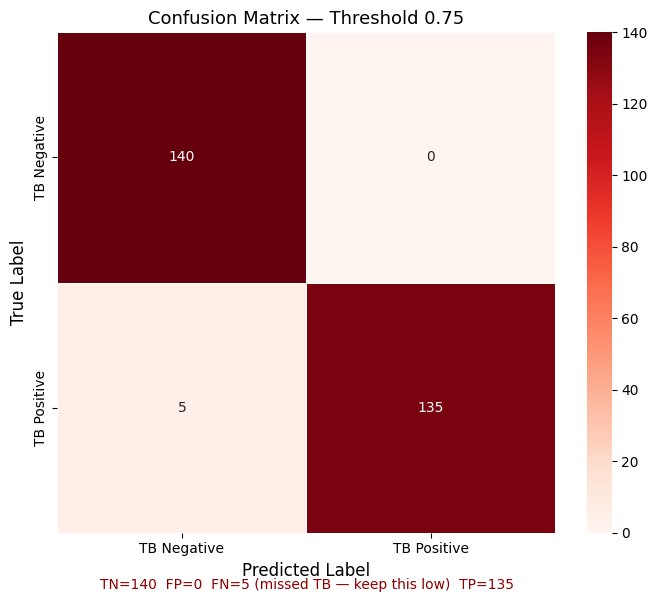


Classification Report:
              precision    recall  f1-score   support

 TB Negative       0.97      1.00      0.98       140
 TB Positive       1.00      0.96      0.98       140

    accuracy                           0.98       280
   macro avg       0.98      0.98      0.98       280
weighted avg       0.98      0.98      0.98       280


Key metric — False Negatives (missed TB): 5
This should be as close to 0 as possible.


In [20]:
# ── Cell 12 — Confusion Matrix ────────────────────────────────────────────────

y_pred_final = (y_pred_probs >= best_threshold).astype(int)
cm = confusion_matrix(y_true, y_pred_final)
tn, fp, fn, tp = cm.ravel()

class_names = ['TB Negative', 'TB Positive']
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Reds',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5
)
plt.title(f'Confusion Matrix — Threshold {best_threshold:.2f}', fontsize=13)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.figtext(0.15, 0.01,
    f"TN={tn}  FP={fp}  FN={fn} (missed TB — keep this low)  TP={tp}",
    fontsize=10, color='darkred')
plt.tight_layout()
plt.savefig('/content/tb_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred_final, target_names=class_names))
print(f"\nKey metric — False Negatives (missed TB): {fn}")
print(f"This should be as close to 0 as possible.")

In [21]:
# ── Cell 13 — Grad-CAM Setup ──────────────────────────────────────────────────
# Grad-CAM visualizes which regions of the X-ray the model focused on
# For TB this should highlight: upper lobes, cavitations, infiltrates
# Red/yellow = high activation, Blue = low activation

# Find last Conv2D layer inside MobileNetV2 sub-model
base_model_ref = model.get_layer('mobilenetv2_1.00_224')

conv_layers = [
    l for l in base_model_ref.layers
    if isinstance(l, tf.keras.layers.Conv2D)
    or isinstance(l, tf.keras.layers.DepthwiseConv2D)
]
LAST_CONV_LAYER = conv_layers[-1].name
print(f"Using last Conv layer: '{LAST_CONV_LAYER}'")

# Build grad_model ONCE — never inside the upload callback
# Building it inside callbacks breaks gradient tape tracking
base_conv_out = base_model_ref.get_layer(LAST_CONV_LAYER).output
base_for_grad = tf.keras.Model(inputs=base_model_ref.input,
                                outputs=base_conv_out)

grad_model = tf.keras.Model(
    inputs=model.input,
    outputs=[base_for_grad(model.input), model.output]
)
print("Grad-CAM model built.")


def get_gradcam_heatmap(img_array):
    img_tensor = tf.cast(img_array, tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        conv_outputs, _ = grad_model(img_tensor, training=False)
        tape.watch(conv_outputs)
    with tf.GradientTape() as tape:
        tape.watch(conv_outputs)
        _, predictions = grad_model(img_tensor, training=False)
        loss = predictions[:, 0]
    grads = tape.gradient(loss, conv_outputs)
    if grads is None:
        print("Warning: grads None — returning uniform heatmap")
        return np.ones((7, 7), dtype=np.float32)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out     = conv_outputs[0]
    heatmap      = conv_out @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.maximum(heatmap, 0)
    max_val      = tf.math.reduce_max(heatmap)
    if max_val == 0:
        return np.zeros(heatmap.shape, dtype=np.float32)
    return (heatmap / max_val).numpy()


def overlay_gradcam(original_img_array, heatmap, alpha=0.4):
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_uint8   = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_rgb     = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    original_uint8  = np.uint8(original_img_array[0] * 255)
    return cv2.addWeighted(original_uint8, 1 - alpha, heatmap_rgb, alpha, 0)


def load_image_any_format(image_bytes):
    """Handles jpg, png, webp, bmp via PIL — cv2 fails on webp in Colab."""
    img = Image.open(io.BytesIO(image_bytes)).convert('RGB')
    img = img.resize((224, 224))
    return img, np.array(img).astype(np.uint8)


def preprocess_for_tb(img_rgb_np):
    """Apply CLAHE + normalize — must match training pipeline exactly."""
    lab     = cv2.cvtColor(img_rgb_np, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe   = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_enh   = clahe.apply(l)
    img_enh = cv2.cvtColor(cv2.merge([l_enh, a, b]), cv2.COLOR_LAB2RGB)
    arr     = img_enh.astype(np.float32) / 255.0
    return np.expand_dims(arr, axis=0), img_enh


# Sanity check
print("\nRunning sanity check...")
dummy = np.random.rand(1, 224, 224, 3).astype(np.float32)
h     = get_gradcam_heatmap(dummy)
print(f"Grad-CAM output shape : {h.shape}")
print("All functions ready.")

Using last Conv layer: 'Conv_1'
Grad-CAM model built.

Running sanity check...
Grad-CAM output shape : (7, 7)
All functions ready.


In [22]:
# ── Cell 14 — Export Model & Metadata ────────────────────────────────────────

model.save('/content/tb_detection_model.h5')
print("Model saved: tb_detection_model.h5")

def get_metric(d, *candidates):
    for key in candidates:
        if key in d:
            return float(d[key])
    return None

metadata = {
    "model_name"         : "tb_detection_model",
    "version"            : "2.0",
    "base_model"         : "MobileNetV2",
    "input_size"         : [224, 224],
    "class_indices"      : train_gen.class_indices,
    "best_threshold"     : float(best_threshold),
    "threshold_strategy" : "recall-optimized (>=0.90 recall target)",
    "preprocessing"      : "CLAHE (clipLimit=2.0, tileGrid=8x8) + rescale 1/255",
    "dataset_balance"    : "1:1 (TB positive : TB negative)",
    "class_weights"      : class_weights,
    "val_accuracy"       : get_metric(metrics_dict, 'accuracy', 'compile_metrics/accuracy'),
    "val_auc"            : get_metric(metrics_dict, 'auc', 'compile_metrics/auc'),
    "val_recall"         : get_metric(metrics_dict, 'recall', 'compile_metrics/recall'),
    "val_precision"      : get_metric(metrics_dict, 'precision', 'compile_metrics/precision'),
    "trained_on"         : "tawsifurrahman TB dataset + paul mooney normals",
    "note"               : "Input images MUST have CLAHE applied before inference"
}

with open('/content/tb_detection_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Metadata saved: tb_detection_metadata.json")
print(json.dumps(metadata, indent=2))

from google.colab import files
files.download('/content/tb_detection_model.h5')
files.download('/content/tb_detection_metadata.json')
files.download('/content/tb_training_curves.png')
files.download('/content/tb_confusion_matrix.png')
files.download('/content/tb_roc_curve.png')

Model saved: tb_detection_model.h5
Metadata saved: tb_detection_metadata.json
{
  "model_name": "tb_detection_model",
  "version": "2.0",
  "base_model": "MobileNetV2",
  "input_size": [
    224,
    224
  ],
  "class_indices": {
    "tb_negative": 0,
    "tb_positive": 1
  },
  "best_threshold": 0.7499999999999998,
  "threshold_strategy": "recall-optimized (>=0.90 recall target)",
  "preprocessing": "CLAHE (clipLimit=2.0, tileGrid=8x8) + rescale 1/255",
  "dataset_balance": "1:1 (TB positive : TB negative)",
  "class_weights": {
    "0": 1.0,
    "1": 1.5
  },
  "val_accuracy": null,
  "val_auc": null,
  "val_recall": null,
  "val_precision": null,
  "trained_on": "tawsifurrahman TB dataset + paul mooney normals",
  "note": "Input images MUST have CLAHE applied before inference"
}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
# ── Cell 15 — Test Cell with Upload & Grad-CAM ────────────────────────────────
# Upload any chest X-ray image (jpg, png, webp supported)
# Shows: Original | CLAHE Enhanced | Grad-CAM heatmap
# Red/yellow in Grad-CAM = regions model focused on for prediction

import ipywidgets as widgets
from IPython.display import display, clear_output

# Re-confirm Grad-CAM layer from Cell 13
base_model_ref  = model.get_layer('mobilenetv2_1.00_224')
conv_layers_ref = [
    l for l in base_model_ref.layers
    if isinstance(l, tf.keras.layers.Conv2D)
    or isinstance(l, tf.keras.layers.DepthwiseConv2D)
]
LAST_CONV_LAYER = conv_layers_ref[-1].name
print(f"Grad-CAM using layer: '{LAST_CONV_LAYER}'")

with open('/content/tb_detection_metadata.json') as f:
    meta = json.load(f)

THRESHOLD     = meta['best_threshold']
CLASS_INDICES = meta['class_indices']
TB_INDEX      = CLASS_INDICES.get('tb_positive', 1)
print(f"Threshold : {THRESHOLD}  |  TB index: {TB_INDEX}")

upload_btn  = widgets.FileUpload(accept='image/*', multiple=False,
                                  description='Upload X-ray')
output_area = widgets.Output()


def on_upload(change):
    with output_area:
        clear_output()

        uploaded_file = list(upload_btn.value.values())[0]
        image_bytes   = uploaded_file['content']
        filename      = uploaded_file['metadata']['name']
        print(f"File : {filename}")
        print(f"Size : {len(image_bytes)/1024:.1f} KB\n")

        try:
            # ── Load (handles webp, jpg, png, bmp) ───────────────────────────
            original_pil, img_rgb_np = load_image_any_format(image_bytes)

            # ── CLAHE + normalize ─────────────────────────────────────────────
            arr, enhanced_img = preprocess_for_tb(img_rgb_np)

            # ── Predict ───────────────────────────────────────────────────────
            raw_score = float(model.predict(arr, verbose=0)[0][0])

            if TB_INDEX == 1:
                tb_prob        = raw_score
                is_tb_positive = raw_score >= THRESHOLD
            else:
                tb_prob        = 1 - raw_score
                is_tb_positive = raw_score < THRESHOLD

            # ── Grad-CAM ──────────────────────────────────────────────────────
            heatmap     = get_gradcam_heatmap(arr)
            gradcam_img = overlay_gradcam(arr, heatmap, alpha=0.45)

            # ── Plot ──────────────────────────────────────────────────────────
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))

            axes[0].imshow(np.array(original_pil))
            axes[0].set_title('Original', fontsize=12)
            axes[0].axis('off')

            axes[1].imshow(enhanced_img)
            axes[1].set_title('CLAHE Enhanced', fontsize=12)
            axes[1].axis('off')

            axes[2].imshow(gradcam_img)
            axes[2].set_title('Grad-CAM — Model Focus', fontsize=12)
            axes[2].axis('off')

            verdict   = "TB POSITIVE" if is_tb_positive else "TB NEGATIVE"
            fig_color = '#c0392b' if is_tb_positive else '#27ae60'

            fig.suptitle(
                f"VERDICT: {verdict}  |  TB Probability: {tb_prob*100:.1f}%",
                fontsize=14, fontweight='bold', color=fig_color
            )
            plt.tight_layout()
            plt.show()

            # ── Text summary ──────────────────────────────────────────────────
            bar_len = int(tb_prob * 30)
            bar     = "\u2588" * bar_len + "\u2591" * (30 - bar_len)

            print("=" * 52)
            print(f"  Verdict         : {verdict}")
            print(f"  TB probability  : {tb_prob*100:.2f}%")
            print(f"  [{bar}]")
            print(f"  Raw score       : {raw_score:.6f}")
            print(f"  Threshold       : {THRESHOLD:.2f}")
            print("-" * 52)
            if is_tb_positive:
                print("  Grad-CAM: red/yellow = regions driving prediction")
                print("  Expected focus: upper lobes, cavitations, infiltrates")
                print("  ACTION: Refer for sputum smear/culture confirmation.")
            else:
                print("  No TB indicators detected at current threshold.")
            print("=" * 52)
            print("\n  REMINDER: Screening aid only — always confirm clinically.")

        except Exception as e:
            print(f"Error: {e}")
            raise e


upload_btn.observe(on_upload, names='value')
print("\nReady — upload a validated chest X-ray:\n")
display(upload_btn, output_area)

Grad-CAM using layer: 'Conv_1'
Threshold : 0.7499999999999998  |  TB index: 1

Ready — upload a validated chest X-ray:



FileUpload(value={}, accept='image/*', description='Upload X-ray')

Output()

In [ ]:
# ── Recovery Cell — Run ONLY if Colab session restarted ──────────────────────
# Colab resets all variables when idle too long
# The model file stays on disk — this recovers everything in ~30 seconds
# without retraining

import tensorflow as tf
import json, cv2, numpy as np
from PIL import Image
import io

model = tf.keras.models.load_model('/content/best_tb_model.h5')
print("Model recovered from /content/best_tb_model.h5")

with open('/content/tb_detection_metadata.json') as f:
    meta = json.load(f)

best_threshold = meta['best_threshold']
class_weights  = meta['class_weights']

print(f"Threshold    : {best_threshold}")
print(f"Class weights: {class_weights}")
print("\nNow rerun Cell 13 and Cell 15 to restore Grad-CAM and test cell.")